In [2]:
import networkx as nx
from networkx.algorithms.community import louvain_communities  # Louvain via NetworkX
import community as community_louvain  # algorithme de Louvain
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt



### Création du graphe à partir du fichier `edgelist`

In [3]:
# pour des résultats reproductibles
np.random.seed(42)

# Chargement du graphe YouTube 
G = nx.read_edgelist("youtube.graph.edgelist", nodetype=int)

N = G.number_of_nodes()
m = G.number_of_edges()
nb_composantes = nx.number_connected_components(G)

print(f"Nombre de nœuds : {N}")
print(f"Nombre d’arêtes : {m}")
print(f"Nombre de composantes connexes : {nb_composantes}")

# Affichage d'un exemple de voisins
example_node = list(G.nodes())[0]
print(f"Exemple de nœud : {example_node}")
print(f"Voisins du nœud {example_node} : {list(G.neighbors(example_node))[:10]}")  # on limite l'affichage


Nombre de nœuds : 22754
Nombre d’arêtes : 65601
Nombre de composantes connexes : 1
Exemple de nœud : 11
Voisins du nœud 11 : [165, 349, 718, 727, 743, 905, 908, 1042, 1073, 1119]


###  Budget et couverture idéaux

In [4]:
def ideal_budget_and_coverage(N, C_0=200):
    """
    Budget idéal : C0 * N
    Couverture idéale : 100%  -> 1 en fraction
    """
    return C_0 * N, 1.0

C_0 = 200
ideal_budget, ideal_coverage = ideal_budget_and_coverage(N, C_0)

print(f"Budget idéal = {ideal_budget:,.2f} CAD")
print(f"Couverture idéale = {ideal_coverage:.0%}")


Budget idéal = 4,550,800.00 CAD
Couverture idéale = 100%


### Détection des communautés (Louvain et LPA)

In [5]:
def get_communities(G, algo="louvain"):
    """
    Retourne un dict {id_communaute: [liste de nœuds]} pour l'algorithme choisi.
    algo ∈ {"louvain", "lpa"}.
    """
    communities = {}

    if algo == "louvain":
        # Utilise l'implémentation Louvain intégrée à NetworkX
        comms = louvain_communities(G, seed=42)
        for i, comm in enumerate(comms):
            communities[i] = list(comm)

    elif algo == "lpa":
        comms = list(nx.algorithms.community.label_propagation_communities(G))
        for i, comm in enumerate(comms):
            communities[i] = list(comm)

    else:
        raise ValueError("Algo inconnu. Utiliser 'louvain' ou 'lpa'.")

    return communities

communities_louvain = get_communities(G, algo="louvain")
communities_lpa = get_communities(G, algo="lpa")

print("Nombre total de communautés (Louvain) :", len(communities_louvain))
print("Nombre total de communautés (LPA) :", len(communities_lpa))



Nombre total de communautés (Louvain) : 30
Nombre total de communautés (LPA) : 1319


### Sélection d'un nœud-influenceur par communauté : Pour chaque communauté, sélectionne un influenceur selon :
    - "closeness"   : centralité de proximité
    - "degree"      : centralité de degré
    - "betweenness" : centralité d'intermédiarité
    - "random"      : nœud aléatoire
    Retourne un dict {id_communaute: {"community": sous-graphe, "influencer": noeud}}.

In [9]:
def get_community_and_profiles(G, communities, influence="closeness"):
    """
    Pour chaque communauté, sélectionne un influenceur selon :
    - "closeness"   : centralité de proximité
    - "degree"      : centralité de degré
    - "betweenness" : centralité d'intermédiarité
    - "random"      : nœud aléatoire
    Retourne un dict {id_communaute: {"community": sous-graphe, "influencer": noeud}}.
    """
    com_and_profiles = {}

    for comm_id, nodes in communities.items():
        community = G.subgraph(nodes)

        if len(community) == 0:
            continue

        if influence == "closeness":
            centrality = nx.closeness_centrality(community)
            influencer = max(centrality, key=centrality.get)

        elif influence == "degree":
            centrality = nx.degree_centrality(community)
            influencer = max(centrality, key=centrality.get)

        elif influence == "betweenness":
            # Attention : peut être lourd, mais c'est ce que demande l'énoncé
            centrality = nx.betweenness_centrality(community)
            influencer = max(centrality, key=centrality.get)

        elif influence == "random":
            influencer = int(np.random.choice(list(nodes)))

        else:
            raise ValueError("Influence inconnue. Utiliser 'closeness', 'degree', 'betweenness' ou 'random'.")

        profile = {"community": community, "influencer": influencer}
        com_and_profiles[comm_id] = profile

    return com_and_profiles

# Exemple : juste pour vérifier que ça marche
com_and_profiles_louvain_closeness = get_community_and_profiles(G, communities_lpa, influence="random")
print("Exemple influenceur (Louvain, closeness) :")
first_comm = list(com_and_profiles_louvain_closeness.keys())[0]
print("Communauté :", first_comm, "Influenceur :", com_and_profiles_louvain_closeness[first_comm]["influencer"])


Exemple influenceur (Louvain, closeness) :
Communauté : 0 Influenceur : 714028


###  Calcul budget / couverture / temps de propagation pour UNE communauté

In [16]:
def get_budget_coverage_per_community(com_and_profile, N, eta=2, C_1=20, C_2=1000):
    """
    Calcule :
    - budget simulé pour une communauté
    - couverture (rapport sur l'ensemble du graphe, donc / N)
    - temps de propagation (somme des temps pour les nœuds influencés)
    """
    community = com_and_profile['community']
    influencer = com_and_profile['influencer']

    # compteur d'individus effectivement influencés (inclut l'influenceur)
    counter = 1
    temps_propagation = 0.0

    # Tirage d'une probabilité p unique pour cet influenceur 
    p = np.random.uniform(0.8, 1.0)

    for node in community.nodes():
        if node == influencer:
            continue

        # tirage aléatoire pour savoir si le nœud est influencé
        choice = np.random.choice([0, 1], p=[1 - p, p])

        if choice == 1:
            try:
                distance = nx.shortest_path_length(community, source=influencer, target=node)
                counter += 1
                # Temps pour ce nœud : η * distance
                temps_propagation += eta * distance
            except nx.NetworkXNoPath:
                # Pas de chemin → impossible à influencer
                continue

    # Budget pour cette communauté :
    # C2 pour contacter l'influenceur + C1 par individu influencé par cet influenceur
    budget = C_2 + (counter - 1) * C_1

    # Couverture : fraction de la population totale N
    coverage = counter / N

    return budget, coverage, temps_propagation


### Calcul budget / couverture / temps pour TOUTES les communautés

In [17]:
def get_budget_and_coverage(com_and_profiles, N, eta=2, C_1=20, C_2=1000):
    total_budget = 0.0
    total_coverage = 0.0
    total_temps_propagation = 0.0

    for comm_id, com_and_profile in com_and_profiles.items():
        budget, coverage, temps_propagation = get_budget_coverage_per_community(
            com_and_profile, N, eta, C_1, C_2
        )
        total_budget += budget
        total_coverage += coverage
        total_temps_propagation += temps_propagation

    return total_budget, total_coverage, total_temps_propagation

# Test rapide sur Louvain + closeness
eta, C_1, C_2 = 2, 20, 1000
sim_budget, sim_coverage, sim_temps = get_budget_and_coverage(
    com_and_profiles_louvain_closeness, N, eta, C_1, C_2
)

print(f"[TEST] Budget simulé = {sim_budget:,.2f} CAD")
print(f"[TEST] Couverture simulée = {sim_coverage:.2%}")
print(f"[TEST] Temps total de propagation = {sim_temps:,.2f} sec")


[TEST] Budget simulé = 449,800.00 CAD
[TEST] Couverture simulée = 92.38%
[TEST] Temps total de propagation = 93,294.00 sec


### Simulation complète pour toutes les combinaisons
 (algo de communautés ∈ {Louvain, LPA} × influence ∈ {closeness, degree, betweenness, random})

In [18]:
eta, C_1, C_2 = 2, 20, 1000

results = []

for algo in ["louvain", "lpa"]:
    if algo == "louvain":
        communities = communities_louvain
    else:
        communities = communities_lpa

    for influence in ["closeness", "degree", "betweenness", "random"]:
        print(f"Simulation - Algo={algo}, Influence={influence} ...")
        start_time = time.time()

        com_and_profiles = get_community_and_profiles(G, communities, influence=influence)
        sim_budget, sim_coverage, sim_temps_propagation = get_budget_and_coverage(
            com_and_profiles, N, eta, C_1, C_2
        )
        exec_time = time.time() - start_time

        results.append({
            "algo": algo,
            "influence": influence,
            "budget": sim_budget,
            "couverture": sim_coverage,
            "temps_propagation": sim_temps_propagation,
            "temps_execution": exec_time
        })

df_results = pd.DataFrame(results)
df_results


Simulation - Algo=louvain, Influence=closeness ...
Simulation - Algo=louvain, Influence=degree ...
Simulation - Algo=louvain, Influence=betweenness ...
Simulation - Algo=louvain, Influence=random ...
Simulation - Algo=lpa, Influence=closeness ...
Simulation - Algo=lpa, Influence=degree ...
Simulation - Algo=lpa, Influence=betweenness ...
Simulation - Algo=lpa, Influence=random ...


,algo,influence,budget,couverture,temps_propagation,temps_execution
0,louvain,closeness,441900.0,0.906434,91450.0,180.080999
1,louvain,degree,432220.0,0.885163,90734.0,4.956000
2,louvain,betweenness,441500.0,0.905555,91828.0,260.485101
3,louvain,random,444720.0,0.912631,158754.0,2.497315
4,lpa,closeness,1711980.0,0.921508,88064.0,2076.556725
5,lpa,degree,1718000.0,0.934737,89490.0,16.082552
6,lpa,betweenness,1700700.0,0.896721,85408.0,3667.381229
7,lpa,random,1736160.0,0.974642,142894.0,6.212273


###  Visualisations basiques

<Figure size 1000x500 with 0 Axes>

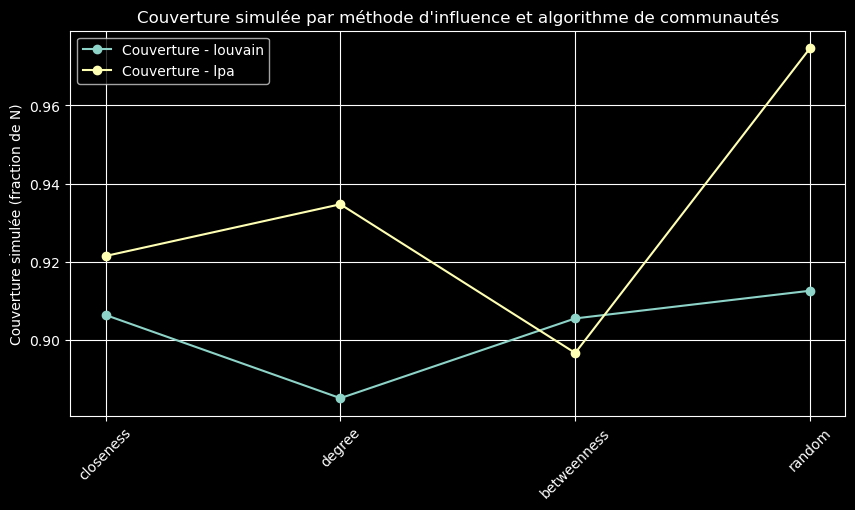

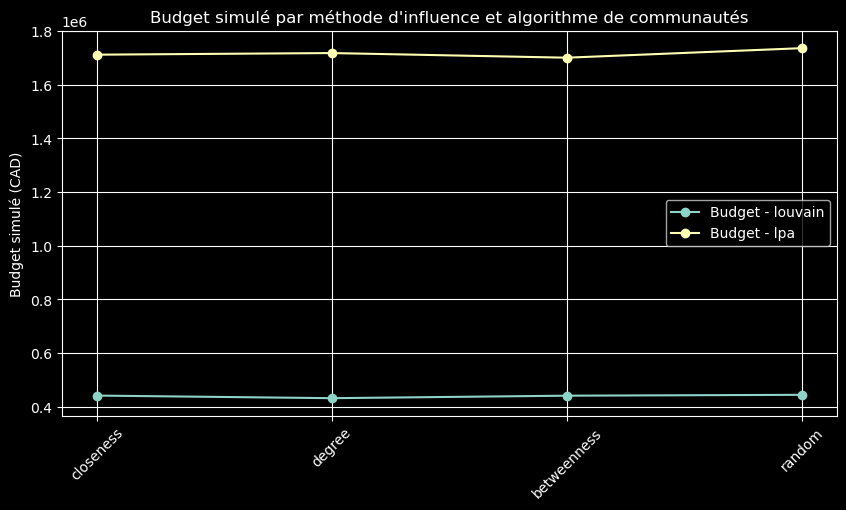

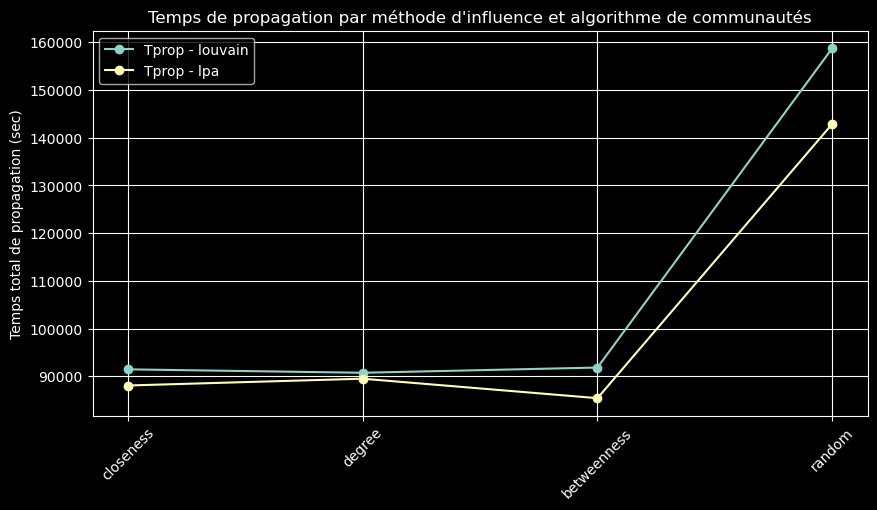

In [19]:


plt.figure(figsize=(10, 5))
for algo in ["louvain", "lpa"]:
    subset = df_results[df_results["algo"] == algo]
    plt.plot(subset["influence"], subset["couverture"], marker="o", label=f"Couverture - {algo}")
plt.ylabel("Couverture simulée (fraction de N)")
plt.title("Couverture simulée par méthode d'influence et algorithme de communautés")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
for algo in ["louvain", "lpa"]:
    subset = df_results[df_results["algo"] == algo]
    plt.plot(subset["influence"], subset["budget"], marker="o", label=f"Budget - {algo}")
plt.ylabel("Budget simulé (CAD)")
plt.title("Budget simulé par méthode d'influence et algorithme de communautés")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
for algo in ["louvain", "lpa"]:
    subset = df_results[df_results["algo"] == algo]
    plt.plot(subset["influence"], subset["temps_propagation"], marker="o", label=f"Tprop - {algo}")
plt.ylabel("Temps total de propagation (sec)")
plt.title("Temps de propagation par méthode d'influence et algorithme de communautés")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()
